In [1]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt

print("OSMnx version:", ox.__version__)

# Pull the drivable road network for the Rochester area, northern Victoria.
# We'll start with Rochester specifically (the town that flooded badly in 2022),
# then expand the study area once we confirm it works.
place = "Rochester, Victoria, Australia"
G = ox.graph_from_place(place, network_type="drive")

print("\nNetwork pulled successfully")
print("Nodes (intersections):", len(G.nodes))
print("Edges (road segments):", len(G.edges))

OSMnx version: 2.1.0

Network pulled successfully
Nodes (intersections): 263
Edges (road segments): 702


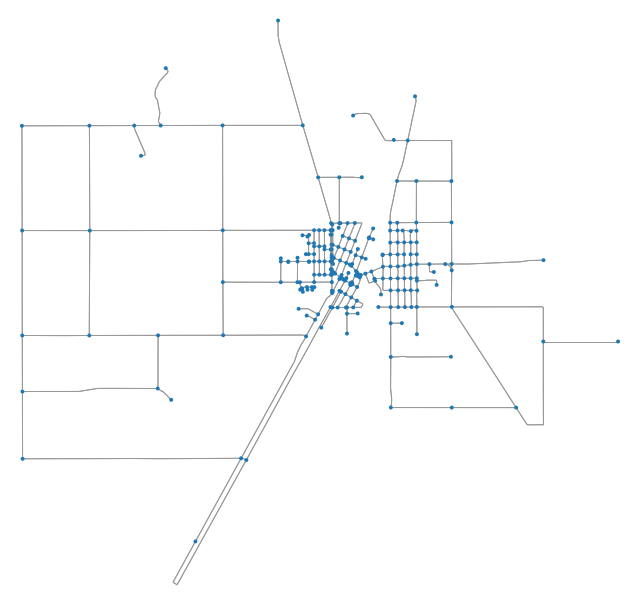

In [2]:
# Plot the raw road network
fig, ax = ox.plot_graph(
    G,
    node_size=8,
    node_color="#1f78b4",
    edge_color="#999999",
    edge_linewidth=0.7,
    bgcolor="white"
)

In [3]:
# Define a bounding box covering Rochester, Echuca, and the connecting road corridor.
# Echuca is ~30km north of Rochester on the Murray; this box covers both + surrounds.
# Format for OSMnx 2.x: bbox = (left, bottom, right, top) in lon/lat (west, south, east, north)
north, south = -36.05, -36.45   # Echuca is ~-36.13, Rochester ~-36.36
east, west = 144.85, 144.45     # spans the corridor between them

bbox = (west, south, east, north)

# Pull the drivable network for the whole box
G = ox.graph_from_bbox(bbox, network_type="drive")

print("Multi-town network pulled")
print("Nodes (intersections):", len(G.nodes))
print("Edges (road segments):", len(G.edges))

Multi-town network pulled
Nodes (intersections): 2449
Edges (road segments): 6107


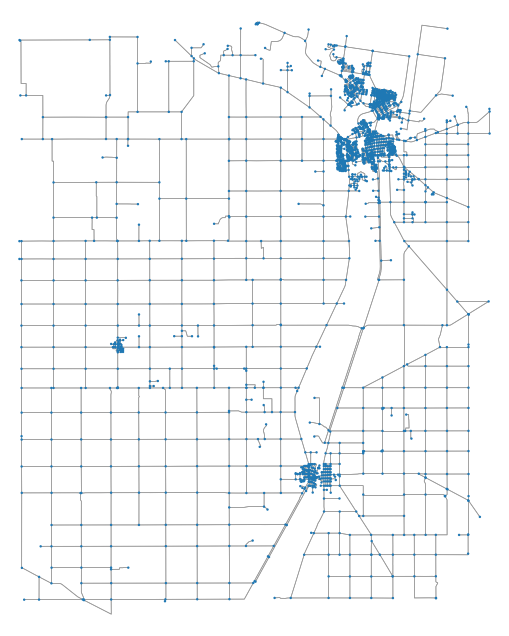

In [4]:
fig, ax = ox.plot_graph(
    G,
    node_size=3,
    node_color="#1f78b4",
    edge_color="#999999",
    edge_linewidth=0.5,
    bgcolor="white"
)

In [5]:
# Save the network so we don't have to re-download from OSM
ox.save_graphml(G, "../data/processed/road_network.graphml")
print("Network saved to data/processed/road_network.graphml")

# Also peek at what road attributes we have — we'll need road type and names later
edges = ox.graph_to_gdfs(G, nodes=False)
print("\nEdge columns available:", edges.columns.tolist())
print("\nRoad types present (highway tag):")
print(edges["highway"].value_counts().head(15))

Network saved to data/processed/road_network.graphml

Edge columns available: ['osmid', 'highway', 'maxspeed', 'name', 'ref', 'oneway', 'reversed', 'length', 'lanes', 'geometry', 'junction', 'bridge', 'service', 'access', 'tunnel', 'width']

Road types present (highway tag):
highway
residential                                   3315
unclassified                                  1500
tertiary                                       453
secondary                                      450
primary                                        296
secondary_link                                  25
primary_link                                    24
[unclassified, residential]                     20
living_street                                   12
tertiary_link                                    4
[unclassified, residential, living_street]       2
[residential, tertiary]                          2
[secondary, unclassified]                        2
[secondary, residential]                         2
Na

In [6]:
# Load the statewide Victorian 1% AEP flood extent
flood_path = "../data/raw/VIC_DEPI_100_Year_Flood_Extent/ll_gda94/extent_100y_ari.shp"
vic_flood = gpd.read_file(flood_path)

print("Flood polygons (statewide):", len(vic_flood))
print("CRS:", vic_flood.crs)
print("Columns:", vic_flood.columns.tolist())

Flood polygons (statewide): 9001
CRS: EPSG:4283
Columns: ['AREA', 'PERIMETER', 'STATION_ID', 'METHOD', 'PLAN_NO', 'SCALE', 'SOURCE', 'NOTE_CODE', 'MODIFIED', 'VERSION', 'geometry']


Flood polygons in study area: 67
CRS: EPSG:4283


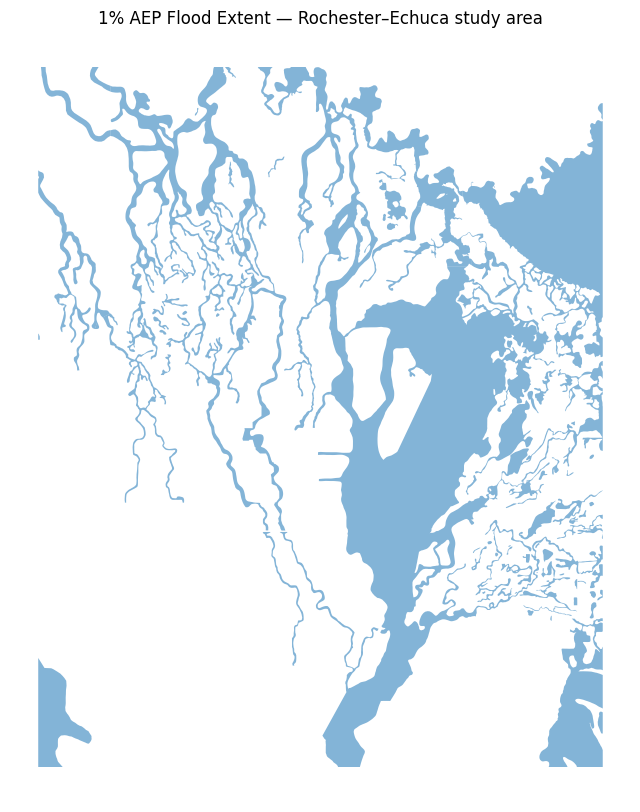

In [7]:
# Clip the statewide flood layer to our study area (same bbox as the road network)
# Our road network bbox was: west=144.45, south=-36.45, east=144.85, north=-36.05
from shapely.geometry import box

# Build a clip box (in the same CRS as the flood data, EPSG:4283 lat/long)
study_box = box(144.45, -36.45, 144.85, -36.05)
study_gdf = gpd.GeoDataFrame(geometry=[study_box], crs="EPSG:4283")

# Clip flood polygons to the study area
flood_clip = gpd.clip(vic_flood, study_gdf)

print("Flood polygons in study area:", len(flood_clip))
print("CRS:", flood_clip.crs)

# Quick plot to see the flood extent in our area
fig, ax = plt.subplots(figsize=(10, 10))
flood_clip.plot(ax=ax, color="#3182bd", alpha=0.6)
ax.set_title("1% AEP Flood Extent — Rochester–Echuca study area")
ax.set_axis_off()
plt.show()

In [8]:
# Convert the road network edges to a GeoDataFrame
edges = ox.graph_to_gdfs(G, nodes=False)
print("Road CRS:", edges.crs)

# Reproject both roads and flood to metric CRS (MGA Zone 55, metres)
edges_m = edges.to_crs("EPSG:7855")
flood_m = flood_clip.to_crs("EPSG:7855")

# Find road segments that intersect any flood polygon
# (spatial join: which edges touch flood water)
flooded = gpd.sjoin(edges_m, flood_m, how="inner", predicate="intersects")

# A road may intersect multiple flood polygons -> get unique flooded edges
flooded_edges = flooded.index.unique()
print("Total road segments:", len(edges_m))
print("Flooded road segments:", len(flooded_edges))
print("Percent of network flooded:", round(100*len(flooded_edges)/len(edges_m), 1), "%")

Road CRS: epsg:4326
Total road segments: 6107
Flooded road segments: 1903
Percent of network flooded: 31.2 %


In [9]:
# Project the whole road graph to metric CRS (MGA Zone 55, metres).
# This fixes nearest_nodes (no scikit-learn needed on a projected graph)
# AND makes all distances/detours come out in metres.
G_proj = ox.project_graph(G, to_crs="EPSG:7855")
print("Graph projected to:", G_proj.graph["crs"])

# Town locations (lat, lon)
towns = {
    "Rochester": (-36.359, 144.702),
    "Echuca": (-36.133, 144.751),
    "Elmore": (-36.495, 144.612),
    "Lockington": (-36.270, 144.547),
    "Kyabram": (-36.315, 144.951),
}

# Reproject each town point to the graph's CRS, then find nearest node
import geopandas as gpd
from shapely.geometry import Point

town_nodes = {}
for name, (lat, lon) in towns.items():
    # make a point in lat/lon, reproject to metric
    pt = gpd.GeoSeries([Point(lon, lat)], crs="EPSG:4326").to_crs("EPSG:7855").iloc[0]
    node = ox.distance.nearest_nodes(G_proj, X=pt.x, Y=pt.y)
    town_nodes[name] = node
    print(f"{name}: node {node}")

print("\nTown nodes located.")

Graph projected to: EPSG:7855
Rochester: node 253000068
Echuca: node 652063599
Elmore: node 3719508946
Lockington: node 6161123059
Kyabram: node 1522744473

Town nodes located.


In [11]:
G_flood = G_proj.copy()

removed = 0
for idx in flooded_edges:
    u, v, k = idx
    if G_flood.has_edge(u, v, k):
        G_flood.remove_edge(u, v, k)
        removed += 1

print(f"Removed {removed} flooded road segments")
print(f"Edges before: {G_proj.number_of_edges()}  after: {G_flood.number_of_edges()}")

import networkx as nx
echuca = town_nodes["Echuca"]

print("\n--- Access to Echuca (regional centre) ---")
for name, node in town_nodes.items():
    if name == "Echuca":
        continue
    try:
        normal = nx.shortest_path_length(G_proj, node, echuca, weight="length")
    except nx.NetworkXNoPath:
        normal = None
    try:
        flooded_dist = nx.shortest_path_length(G_flood, node, echuca, weight="length")
    except nx.NetworkXNoPath:
        flooded_dist = None

    if normal is None:
        print(f"{name}: no normal route (check data)")
    elif flooded_dist is None:
        print(f"{name}: CUT OFF when flooded (normal route was {normal/1000:.1f} km)")
    else:
        extra = flooded_dist - normal
        print(f"{name}: {normal/1000:.1f} km -> {flooded_dist/1000:.1f} km  (+{extra/1000:.1f} km detour)")

Removed 1903 flooded road segments
Edges before: 6107  after: 4204

--- Access to Echuca (regional centre) ---
Rochester: CUT OFF when flooded (normal route was 26.9 km)
Elmore: CUT OFF when flooded (normal route was 41.3 km)
Lockington: CUT OFF when flooded (normal route was 31.2 km)
Kyabram: CUT OFF when flooded (normal route was 23.0 km)


In [12]:
import networkx as nx

# How big is the connected "island" each town sits on after flooding?
# If a town can only reach a handful of nodes, it's genuinely isolated.
# If it can reach thousands, it's connected to a large area (just not Echuca).

print("--- Connectivity islands after flooding ---")
for name, node in town_nodes.items():
    # nodes reachable from this town in the flooded network
    reachable = nx.node_connected_component(G_flood.to_undirected(), node)
    print(f"{name}: can still reach {len(reachable)} of {G_flood.number_of_nodes()} nodes")

# Also: are the towns isolated from each other, or clustered together?
print("\n--- Can towns still reach each OTHER when flooded? ---")
names = list(town_nodes.keys())
for i, a in enumerate(names):
    for b in names[i+1:]:
        try:
            d = nx.shortest_path_length(G_flood, town_nodes[a], town_nodes[b], weight="length")
            print(f"{a} <-> {b}: {d/1000:.1f} km")
        except nx.NetworkXNoPath:
            print(f"{a} <-> {b}: CUT OFF from each other")

--- Connectivity islands after flooding ---
Rochester: can still reach 1 of 2449 nodes
Echuca: can still reach 335 of 2449 nodes
Elmore: can still reach 247 of 2449 nodes
Lockington: can still reach 247 of 2449 nodes
Kyabram: can still reach 1 of 2449 nodes

--- Can towns still reach each OTHER when flooded? ---
Rochester <-> Echuca: CUT OFF from each other
Rochester <-> Elmore: CUT OFF from each other
Rochester <-> Lockington: CUT OFF from each other
Rochester <-> Kyabram: CUT OFF from each other
Echuca <-> Elmore: CUT OFF from each other
Echuca <-> Lockington: CUT OFF from each other
Echuca <-> Kyabram: CUT OFF from each other
Elmore <-> Lockington: 23.4 km
Elmore <-> Kyabram: CUT OFF from each other
Lockington <-> Kyabram: CUT OFF from each other


In [13]:
# Diagnose the orphaned towns: how connected were Rochester & Kyabram BEFORE flooding?
import networkx as nx

print("--- Pre-flood connectivity (sanity check the town nodes) ---")
for name, node in town_nodes.items():
    deg = G_proj.degree(node)
    reachable_normal = len(nx.node_connected_component(G_proj.to_undirected(), node))
    print(f"{name}: node degree {deg}, reaches {reachable_normal} nodes normally")

--- Pre-flood connectivity (sanity check the town nodes) ---
Rochester: node degree 6, reaches 2449 nodes normally
Echuca: node degree 8, reaches 2449 nodes normally
Elmore: node degree 6, reaches 2449 nodes normally
Lockington: node degree 6, reaches 2449 nodes normally
Kyabram: node degree 6, reaches 2449 nodes normally


In [14]:
# Save the flooded-network analysis results to a small summary
import pandas as pd

results = []
echuca = town_nodes["Echuca"]
for name, node in town_nodes.items():
    if name == "Echuca":
        continue
    normal = nx.shortest_path_length(G_proj, node, echuca, weight="length")
    try:
        flooded_dist = nx.shortest_path_length(G_flood, node, echuca, weight="length")
        status = "Detour"
    except nx.NetworkXNoPath:
        flooded_dist = None
        status = "CUT OFF"
    island = len(nx.node_connected_component(G_flood.to_undirected(), node))
    results.append({
        "town": name,
        "normal_km_to_echuca": round(normal/1000, 1),
        "flooded_km_to_echuca": round(flooded_dist/1000, 1) if flooded_dist else None,
        "status": status,
        "reachable_nodes_when_flooded": island
    })

summary = pd.DataFrame(results)
import os
os.makedirs("../outputs", exist_ok=True)
summary.to_csv("../outputs/town_access_summary.csv", index=False)
print(summary.to_string(index=False))
print("\nSaved to outputs/town_access_summary.csv")

      town  normal_km_to_echuca flooded_km_to_echuca  status  reachable_nodes_when_flooded
 Rochester                 26.9                 None CUT OFF                             1
    Elmore                 41.3                 None CUT OFF                           247
Lockington                 31.2                 None CUT OFF                           247
   Kyabram                 23.0                 None CUT OFF                             1

Saved to outputs/town_access_summary.csv


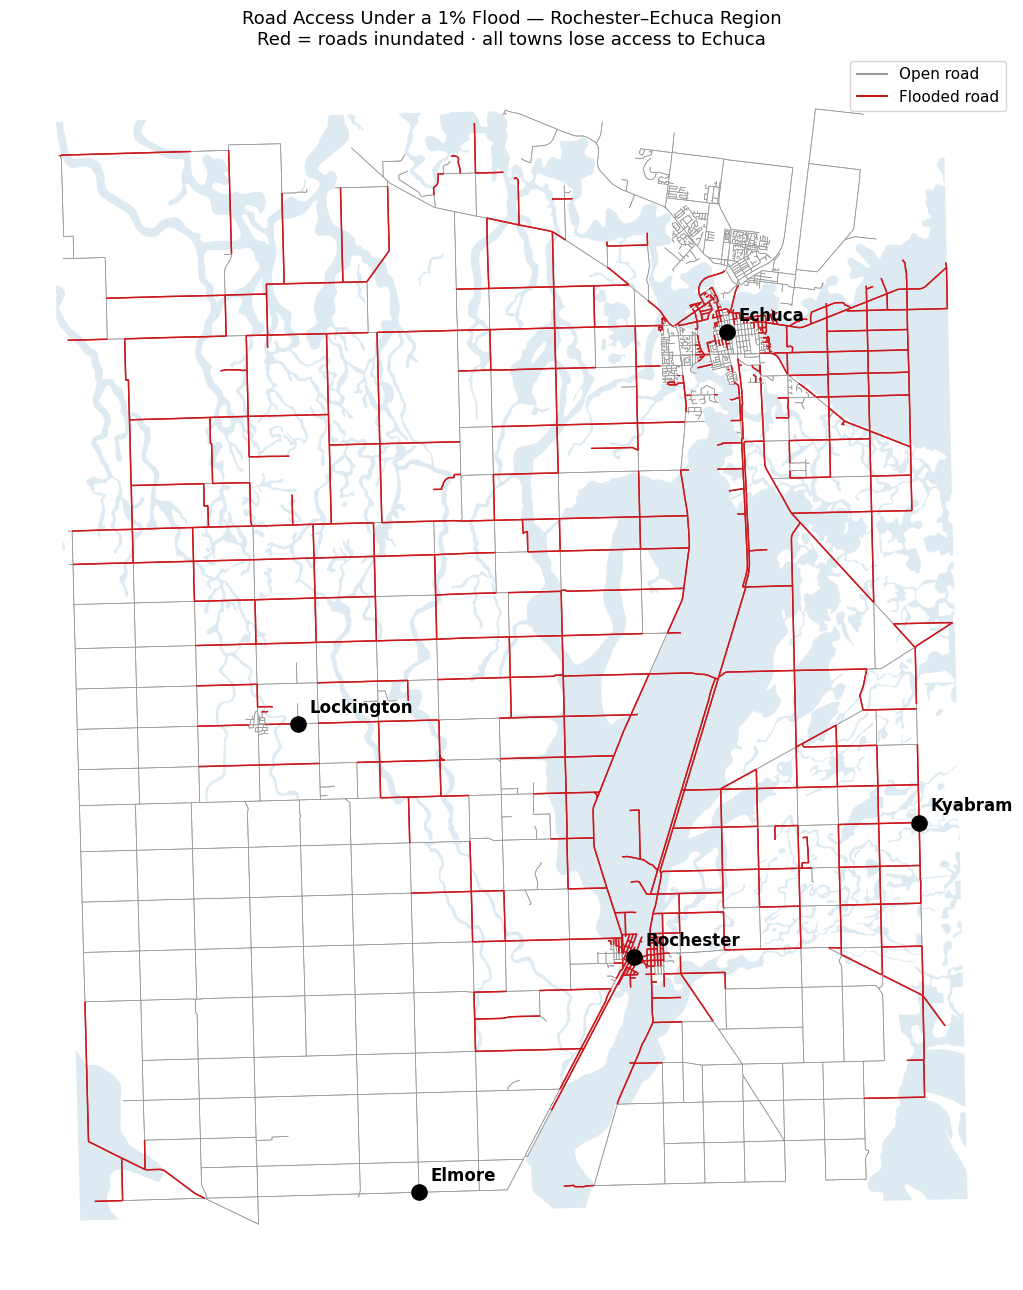

Map saved to outputs/flood_road_access_map.png


In [15]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Get edge GeoDataFrame for the projected graph, flag which are flooded
edges_proj = ox.graph_to_gdfs(G_proj, nodes=False)
edges_proj = edges_proj.reset_index()  # so u,v,key become columns

# Mark flooded edges
flooded_set = set(flooded_edges)
edges_proj["is_flooded"] = edges_proj.apply(
    lambda r: (r["u"], r["v"], r["key"]) in flooded_set, axis=1
)

# Flood polygons in same CRS
flood_proj = flood_clip.to_crs("EPSG:7855")

fig, ax = plt.subplots(figsize=(13, 13))

# Flood extent (light blue fill)
flood_proj.plot(ax=ax, color="#bdd7e7", alpha=0.5, zorder=0)

# Dry roads (grey) and flooded roads (red)
edges_proj[~edges_proj["is_flooded"]].plot(ax=ax, color="#999999", linewidth=0.5, zorder=1)
edges_proj[edges_proj["is_flooded"]].plot(ax=ax, color="#cb181d", linewidth=1.0, zorder=2)

# Town markers
nodes_proj = ox.graph_to_gdfs(G_proj, edges=False)
for name, node in town_nodes.items():
    pt = nodes_proj.loc[node]
    ax.scatter(pt.geometry.x, pt.geometry.y, s=120, c="black", zorder=4)
    ax.annotate(name, (pt.geometry.x, pt.geometry.y),
                xytext=(8, 8), textcoords="offset points",
                fontsize=12, fontweight="bold", zorder=5)

ax.set_title("Road Access Under a 1% Flood — Rochester–Echuca Region\n"
             "Red = roads inundated · all towns lose access to Echuca", fontsize=13)
ax.set_axis_off()

# Legend
dry = mlines.Line2D([], [], color="#999999", label="Open road")
wet = mlines.Line2D([], [], color="#cb181d", label="Flooded road")
ax.legend(handles=[dry, wet], loc="upper right", fontsize=11)

plt.tight_layout()
plt.savefig("../outputs/flood_road_access_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Map saved to outputs/flood_road_access_map.png")

Flooding splits the network into 619 disconnected pieces


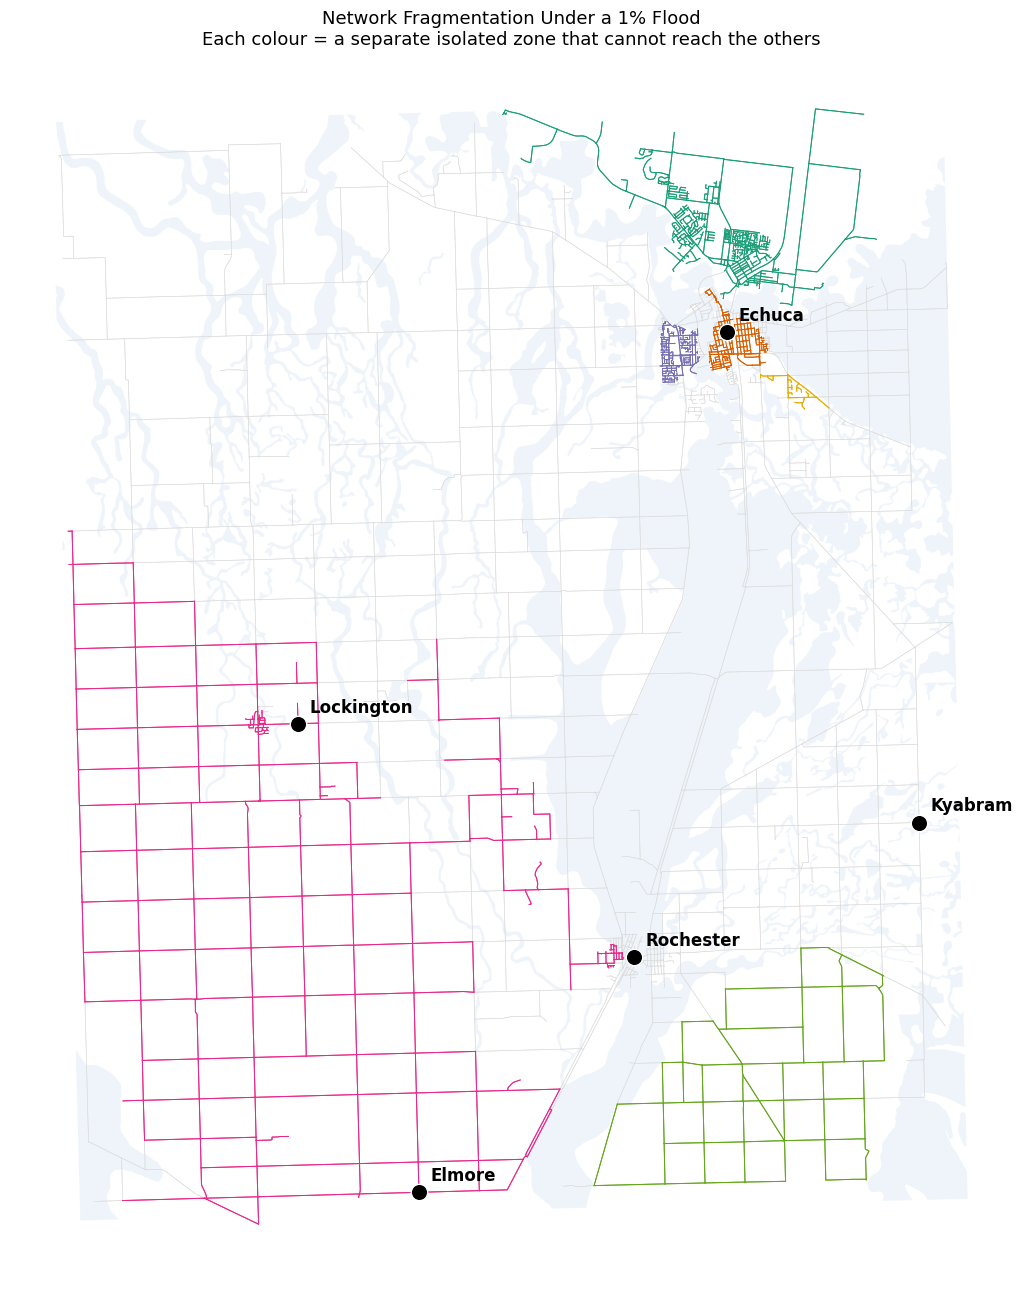

Saved to outputs/flood_fragmentation_map.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Find all connected components (islands) in the flooded network
undirected_flood = G_flood.to_undirected()
components = list(nx.connected_components(undirected_flood))
print(f"Flooding splits the network into {len(components)} disconnected pieces")

# Map each node to its component, but only color the BIG components distinctly
# (tiny 1-2 node fragments would be visual noise)
big_comps = sorted(components, key=len, reverse=True)[:6]  # top 6 by size

# Assign a color to each big component
colors = ["#1b9e77", "#d95f02", "#7570b3", "#e7298a", "#66a61e", "#e6ab02"]
node_color = {}
for i, comp in enumerate(big_comps):
    for n in comp:
        node_color[n] = colors[i]

edges_proj = ox.graph_to_gdfs(G_proj, nodes=False).reset_index()

fig, ax = plt.subplots(figsize=(13, 13))
flood_proj.plot(ax=ax, color="#deebf7", alpha=0.5, zorder=0)

# Draw each edge colored by which island its nodes belong to (grey if cut/tiny fragment)
for _, row in edges_proj.iterrows():
    u, v = row["u"], row["v"]
    c = node_color.get(u) if node_color.get(u) == node_color.get(v) else None
    if c:
        ax.plot(*row.geometry.xy, color=c, linewidth=0.7, zorder=1)
    else:
        ax.plot(*row.geometry.xy, color="#dddddd", linewidth=0.4, zorder=0.5)

# Town markers
nodes_proj = ox.graph_to_gdfs(G_proj, edges=False)
for name, node in town_nodes.items():
    pt = nodes_proj.loc[node]
    ax.scatter(pt.geometry.x, pt.geometry.y, s=140, c="black", zorder=4, edgecolors="white")
    ax.annotate(name, (pt.geometry.x, pt.geometry.y), xytext=(8, 8),
                textcoords="offset points", fontsize=12, fontweight="bold", zorder=5)

ax.set_title("Network Fragmentation Under a 1% Flood\n"
             "Each colour = a separate isolated zone that cannot reach the others", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/flood_fragmentation_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/flood_fragmentation_map.png")